In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./weight-height.csv")
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


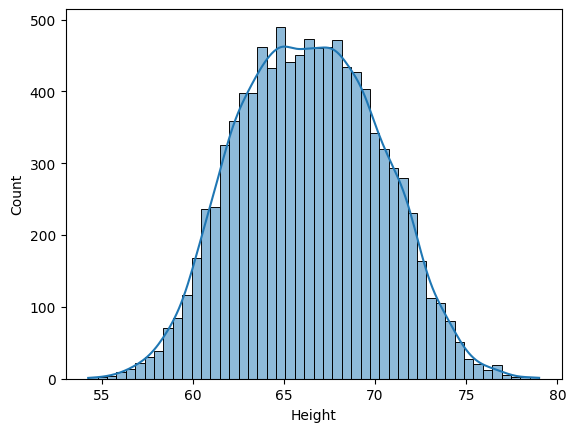

In [3]:
sns.histplot(df["Height"], kde=True)
plt.show()

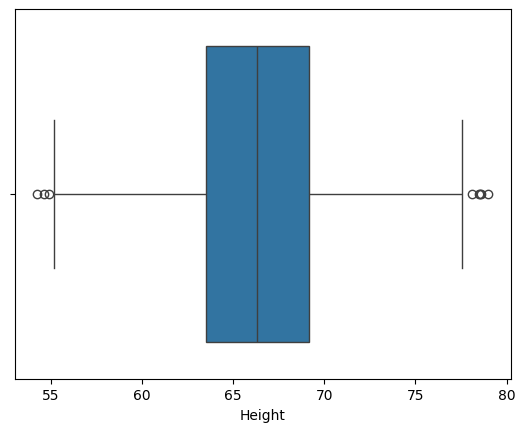

In [4]:
sns.boxplot(x=df["Height"])
plt.show()

In [5]:
upper_limit = df["Height"].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [6]:
lower_limit = df["Height"].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [14]:
# Trimming 
new_df = df[(df["Height"] <= 74.78) & (df["Height"] >= 58.13)]
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [15]:
new_df["Height"].describe()

count    9799.000000
mean       66.363507
std         3.644267
min        58.134496
25%        63.577147
50%        66.317899
75%        69.119859
max        74.767447
Name: Height, dtype: float64

In [16]:
df["Height"].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

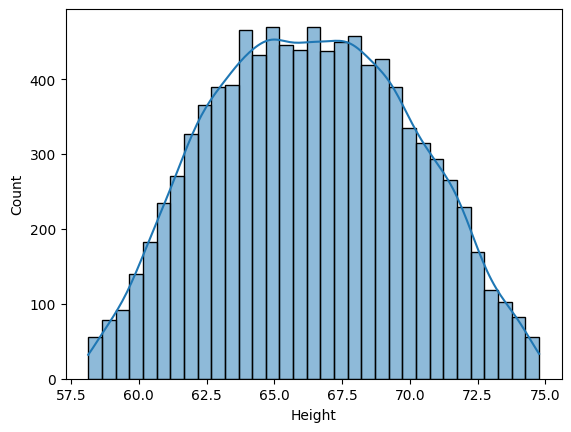

In [17]:
sns.histplot(new_df["Height"], kde=True)
plt.show()

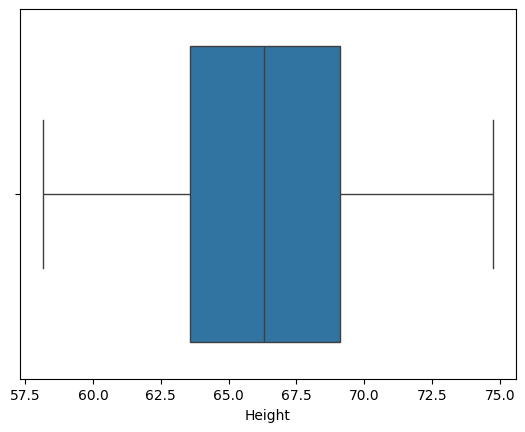

In [18]:
sns.boxplot(x=new_df["Height"])
plt.show()

In [20]:
# Capping - Winsorization 
df["Height"] = np.where(
    df["Height"] >= upper_limit,
    upper_limit,
    np.where(
        df["Height"] <= lower_limit,
        lower_limit,
        df["Height"]
    )
)

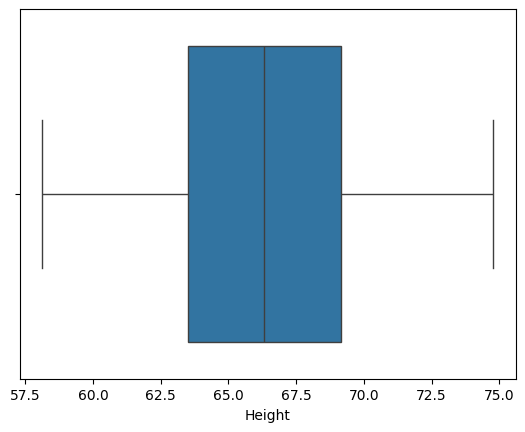

In [21]:
sns.boxplot(x=df["Height"])
plt.show()